In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.chdir('/content/drive/MyDrive/biomedical-nlp-project-beta')

Mounted at /content/drive


In [6]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pytorch-crf', 'sklearn-crfsuite', 'seqeval'], check=True)
print('Dependencies ready.')

Dependencies ready.


---
# Notebook 07 — NER Error Analysis

We have trained four progressively more sophisticated models for disease NER on the NCBI Disease corpus:

| # | Method | Core idea |
|---|--------|-----------|
| 02 | **Rule-Based** | Dictionary lookup + medical suffixes |
| 03 | **CRF** | Hand-crafted features + sequence modelling |
| 05 | **BiLSTM** | Neural context + pre-trained embeddings |
| 06 | **BiLSTM-CRF** | Neural context + structural decoding |

This notebook asks: **where does each model fail, and why?**

We reconstruct or reload every model, re-run predictions on the test set, and break errors into three interpretable categories:
- **Multi-word entity misses** — spans of 2+ tokens the model got wrong
- **Abbreviation misses** — short all-caps tokens (DM, COPD, MS, …)
- **Single-word entity misses** — individual disease tokens the model missed

We then trace 5 hard sentences through all four models and close with a clean narrative of what each technique contributed.

In [7]:
import os, json, re
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    print(f'Changed CWD to: {os.getcwd()}')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import sklearn_crfsuite
from torchcrf import CRF
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LABEL_MAP  = {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}
PAD_IDX    = 0
UNK_IDX    = 1
PAD_LABEL  = -100
MAX_LENGTH = 128
NUM_TAGS   = 3

# Consistent ordering and colours for all plots
MODEL_DISPLAY = ['Rule-Based', 'CRF', 'BiLSTM', 'BiLSTM-CRF']
MODEL_KEYS    = ['rule_based', 'crf', 'bilstm', 'bilstm_crf']
MODEL_COLORS  = ['#4878D0', '#EE854A', '#6ACC64', '#D65F5F']

# Global matplotlib style
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        12,
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
os.makedirs('results', exist_ok=True)

Device: cpu


---
## Step 1 — Load NCBI Disease Dataset

In [8]:
PARQUET_BASE = 'hf://datasets/ncbi_disease@refs/convert/parquet/ncbi_disease'
df_train = pd.read_parquet(f'{PARQUET_BASE}/train/0000.parquet')
df_val   = pd.read_parquet(f'{PARQUET_BASE}/validation/0000.parquet')
df_test  = pd.read_parquet(f'{PARQUET_BASE}/test/0000.parquet')

# Keep only well-formed test rows
df_test = df_test[
    df_test.apply(lambda r: len(r['tokens']) > 0 and
                            len(r['tokens']) == len(r['ner_tags']), axis=1)
].reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

# Build master-aligned lists for error analysis
tokens_list = []
y_true_list = []
for _, row in df_test.iterrows():
    tokens = list(row['tokens'])
    y_true = [
        LABEL_MAP.get(int(t), 'O') if isinstance(t, (int, np.integer)) else str(t)
        for t in row['ner_tags']
    ]
    tokens_list.append(tokens)
    y_true_list.append(y_true)

print(f'Aligned test sentences: {len(tokens_list)}')

Train: 5433 | Val: 924 | Test: 940
Aligned test sentences: 940


---
## Step 2 — Load Shared Artefacts

In [9]:
with open('models/word2idx.json') as f:
    word2idx = json.load(f)

embedding_matrix = np.load('models/embedding_matrix.npy')
vocab_size, embedding_dim = embedding_matrix.shape
print(f'Vocab size : {vocab_size:,}')
print(f'Embedding  : {embedding_dim}d')


def tokens_to_indices(tokens, word2idx, max_length=MAX_LENGTH):
    indices = [word2idx.get(tok, UNK_IDX) for tok in tokens[:max_length]]
    return indices + [PAD_IDX] * (max_length - len(indices))

Vocab size : 8,387
Embedding  : 200d


---
## Step 3 — Rebuild / Reload All Four Models

### 3a — Rule-Based (dictionary + medical suffixes)

In [10]:
# Build disease dictionary from training labels (same logic as notebook 02)
disease_dict = set()
for _, row in df_train.iterrows():
    tokens   = list(row['tokens'])
    ner_tags = list(row['ner_tags'])
    current  = []
    for tok, tag in zip(tokens, ner_tags):
        tag_int = int(tag) if isinstance(tag, (int, np.integer)) else \
                  {'O': 0, 'B-Disease': 1, 'I-Disease': 2}.get(str(tag), 0)
        if tag_int == 1:
            if current:
                ent = ' '.join(current)
                disease_dict.update([ent, ent.lower()])
            current = [tok]
        elif tag_int == 2:
            current.append(tok)
        else:
            if current:
                ent = ' '.join(current)
                disease_dict.update([ent, ent.lower()])
                current = []
    if current:
        ent = ' '.join(current)
        disease_dict.update([ent, ent.lower()])

print(f'Disease dictionary: {len(disease_dict)} entries')

MEDICAL_SUFFIXES_RB = ('itis', 'osis', 'emia', 'oma', 'pathy',
                        'plasia', 'trophy', 'ectomy')

def _has_suffix_rb(token):
    return any(token.lower().endswith(s) for s in MEDICAL_SUFFIXES_RB)


def predict_rule_based(tokens):
    """Longest-match dictionary scan + medical suffix fallback."""
    n     = len(tokens)
    preds = ['O'] * n
    i     = 0
    while i < n:
        matched = False
        for window in range(min(4, n - i), 0, -1):
            span = ' '.join(tokens[i:i + window])
            if span in disease_dict or span.lower() in disease_dict:
                preds[i] = 'B-Disease'
                for k in range(1, window):
                    preds[i + k] = 'I-Disease'
                i      += window
                matched = True
                break
        if not matched:
            if _has_suffix_rb(tokens[i]):
                preds[i] = 'B-Disease'
            i += 1
    return preds


y_pred_rb = [predict_rule_based(toks) for toks in tokens_list]
print(f'Rule-Based F1 = {f1_score(y_true_list, y_pred_rb):.4f}  (reported 0.5771)')

Disease dictionary: 2229 entries
Rule-Based F1 = 0.5775  (reported 0.5771)


### 3b — CRF (sklearn-crfsuite, retrained with best hyperparameters)

In [11]:
# ── Feature engineering (identical to notebook 03) ────────────────────────
MEDICAL_SUFFIXES_CRF = ('itis', 'osis', 'emia', 'oma', 'pathy',
                         'plasia', 'ectomy', 'uria', 'trophy', 'sclerosis')

def _has_suffix_crf(word):
    return any(word.lower().endswith(s) for s in MEDICAL_SUFFIXES_CRF)


def word2features(sent, i):
    word = sent[i]
    wl   = word.lower()
    feats = {
        'bias':                1.0,
        'word.lower':          wl,
        'word.isupper':        word.isupper(),
        'word.istitle':        word.istitle(),
        'word.isdigit':        word.isdigit(),
        'word.len':            len(word),
        'word[-3:]':           wl[-3:],
        'word[-5:]':           wl[-5:],
        'word[:3]':            wl[:3],
        'has_hyphen':          '-' in word,
        'has_digit':           any(c.isdigit() for c in word),
        'has_medical_suffix':  _has_suffix_crf(word),
    }
    if i == 0:
        feats['BOS'] = True
    else:
        pw  = sent[i - 1]
        pwl = pw.lower()
        feats.update({
            '-1:word.lower':          pwl,
            '-1:word.isupper':        pw.isupper(),
            '-1:word.istitle':        pw.istitle(),
            '-1:word[-3:]':           pwl[-3:],
            '-1:has_medical_suffix':  _has_suffix_crf(pw),
        })
    if i == len(sent) - 1:
        feats['EOS'] = True
    else:
        nw  = sent[i + 1]
        nwl = nw.lower()
        feats.update({
            '+1:word.lower':          nwl,
            '+1:word.isupper':        nw.isupper(),
            '+1:word.istitle':        nw.istitle(),
            '+1:word[-3:]':           nwl[-3:],
            '+1:has_medical_suffix':  _has_suffix_crf(nw),
        })
    if i < len(sent) - 1:
        feats['bigram'] = wl + '_' + sent[i + 1].lower()
    return feats


def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]


def sent2labels(tags):
    return [
        LABEL_MAP.get(int(t), 'O') if isinstance(t, (int, np.integer)) else str(t)
        for t in tags
    ]


def df_to_XY(df):
    X, y = [], []
    for _, row in df.iterrows():
        toks = list(row['tokens'])
        tags = list(row['ner_tags'])
        if not toks:
            continue
        X.append(sent2features(toks))
        y.append(sent2labels(tags))
    return X, y


print('Extracting CRF features (train + val)...')
X_tr, y_tr = df_to_XY(df_train)
X_vl, y_vl = df_to_XY(df_val)
print(f'  Train: {len(X_tr)} | Val: {len(X_vl)}')

# Best hyperparameters from notebook 03 grid search: c1=0.01, c2=0.1
# Trained on train+val combined, identical to notebook 03's final model
print('Training CRF on train + val...')
crf_model = sklearn_crfsuite.CRF(
    algorithm='lbfgs', c1=0.01, c2=0.1,
    max_iterations=200, all_possible_transitions=True
)
crf_model.fit(X_tr + X_vl, y_tr + y_vl)
print('CRF trained.')

X_test_crf  = [sent2features(toks) for toks in tokens_list]
y_pred_crf  = crf_model.predict(X_test_crf)
print(f'CRF F1 = {f1_score(y_true_list, y_pred_crf):.4f}  (reported 0.7825)')

Extracting CRF features (train + val)...
  Train: 5432 | Val: 923
Training CRF on train + val...
CRF trained.
CRF F1 = 0.7815  (reported 0.7825)


### 3c — BiLSTM (load checkpoint from notebook 05)

In [12]:
class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_labels, lstm_dropout, fc_dropout,
                 pretrained_embeddings=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(pretrained_embeddings).float()
            )
        if freeze_emb:
            self.embedding.weight.requires_grad = False
        self.lstm    = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers,
                               bidirectional=True, dropout=lstm_dropout, batch_first=True)
        self.dropout = nn.Dropout(fc_dropout)
        self.fc      = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, x):
        out      = self.embedding(x)
        out, _   = self.lstm(out)
        out      = self.dropout(out)
        return self.fc(out)


bilstm = BiLSTM_NER(
    vocab_size=vocab_size, embedding_dim=embedding_dim,
    hidden_size=256, num_layers=2, num_labels=NUM_TAGS,
    lstm_dropout=0.3, fc_dropout=0.5,
    pretrained_embeddings=embedding_matrix
).to(device)
bilstm.load_state_dict(torch.load('models/bilstm_ner.pt', map_location=device))
bilstm.eval()
print('BiLSTM checkpoint loaded.')

y_pred_bilstm = []
with torch.no_grad():
    for tokens in tokens_list:
        real_len = len(tokens)
        x_t      = torch.tensor([tokens_to_indices(tokens, word2idx)],
                                dtype=torch.long).to(device)
        logits   = bilstm(x_t)                        # (1, 128, 3)
        pred     = logits.argmax(dim=-1)[0, :real_len] # real tokens only
        y_pred_bilstm.append([LABEL_MAP[p.item()] for p in pred])

print(f'BiLSTM F1 = {f1_score(y_true_list, y_pred_bilstm):.4f}  (reported 0.6827)')

BiLSTM checkpoint loaded.
BiLSTM F1 = 0.6827  (reported 0.6827)


### 3d — BiLSTM-CRF (load checkpoint from notebook 06)

In [13]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_tags, lstm_dropout, fc_dropout,
                 pretrained_embeddings=None, freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(pretrained_embeddings).float()
            )
        if freeze_emb:
            self.embedding.weight.requires_grad = False
        self.lstm    = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers,
                               bidirectional=True, dropout=lstm_dropout, batch_first=True)
        self.dropout = nn.Dropout(fc_dropout)
        self.fc      = nn.Linear(hidden_size * 2, num_tags)
        self.crf     = CRF(num_tags=num_tags, batch_first=True)

    def _emissions(self, x):
        out     = self.embedding(x)
        out, _  = self.lstm(out)
        return self.fc(self.dropout(out))

    def forward(self, x, labels=None, mask=None):
        e = self._emissions(x)
        if labels is not None:
            if mask is None:
                mask = (labels != PAD_LABEL)
            clean          = labels.clone()
            clean[clean == PAD_LABEL] = 0
            return -self.crf(e, clean, mask=mask, reduction='mean')
        return self.crf.decode(e, mask=mask)


bilstm_crf = BiLSTM_CRF(
    vocab_size=vocab_size, embedding_dim=embedding_dim,
    hidden_size=256, num_layers=2, num_tags=NUM_TAGS,
    lstm_dropout=0.3, fc_dropout=0.5,
    pretrained_embeddings=embedding_matrix
).to(device)
bilstm_crf.load_state_dict(
    torch.load('models/bilstm_crf_ner.pt', map_location=device)
)
bilstm_crf.eval()
print('BiLSTM-CRF checkpoint loaded.')

y_pred_bilstm_crf = []
with torch.no_grad():
    for tokens in tokens_list:
        real_len = len(tokens)
        x_t      = torch.tensor([tokens_to_indices(tokens, word2idx)],
                                dtype=torch.long).to(device)
        mask_t   = torch.zeros(1, MAX_LENGTH, dtype=torch.bool, device=device)
        mask_t[0, :real_len] = True
        pred = bilstm_crf(x_t, mask=mask_t)   # list[list[int]]
        y_pred_bilstm_crf.append([LABEL_MAP[p] for p in pred[0]])

print(f'BiLSTM-CRF F1 = {f1_score(y_true_list, y_pred_bilstm_crf):.4f}  (reported 0.7514)')

BiLSTM-CRF checkpoint loaded.
BiLSTM-CRF F1 = 0.5448  (reported 0.7514)


In [14]:
# Master prediction dictionary (used throughout the notebook)
y_preds = {
    'Rule-Based':  y_pred_rb,
    'CRF':         y_pred_crf,
    'BiLSTM':      y_pred_bilstm,
    'BiLSTM-CRF':  y_pred_bilstm_crf,
}

print(f'{"Model":<14}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}')
print('-' * 48)
for name in MODEL_DISPLAY:
    preds = y_preds[name]
    p = precision_score(y_true_list, preds)
    r = recall_score(y_true_list, preds)
    f = f1_score(y_true_list, preds)
    print(f'{name:<14}  {p:>10.4f}  {r:>8.4f}  {f:>8.4f}')

Model            Precision    Recall        F1
------------------------------------------------
Rule-Based          0.5383    0.6229    0.5775
CRF                 0.8310    0.7375    0.7815
BiLSTM              0.6874    0.6781    0.6827
BiLSTM-CRF          0.7133    0.4406    0.5448


---
## Step 4 — Master Comparison Table

In [15]:
with open('results/ner_results.json') as f:
    results_list = json.load(f)
res = {r['method']: r for r in results_list}

DISPLAY_MAP = {
    'rule_based':  'Rule-Based',
    'crf':         'CRF (sklearn)',
    'bilstm':      'BiLSTM',
    'bilstm_crf':  'BiLSTM + CRF',
}

rows = []
for key in MODEL_KEYS:
    r = res.get(key, {})
    rows.append({
        'Model':     DISPLAY_MAP[key],
        'Precision': r.get('precision', 0),
        'Recall':    r.get('recall',    0),
        'F1':        r.get('f1',        0),
    })

df_results = pd.DataFrame(rows)
print('=== NER Model Comparison (Test Set) ===')
print(df_results.to_string(index=False, float_format='{:.4f}'.format))

=== NER Model Comparison (Test Set) ===
        Model  Precision  Recall     F1
   Rule-Based     0.5378  0.6225 0.5771
CRF (sklearn)     0.8347  0.7365 0.7825
       BiLSTM     0.6874  0.6781 0.6827
 BiLSTM + CRF     0.8031  0.7059 0.7514


---
## Step 5 — F1 Bar Chart (Publication Quality)

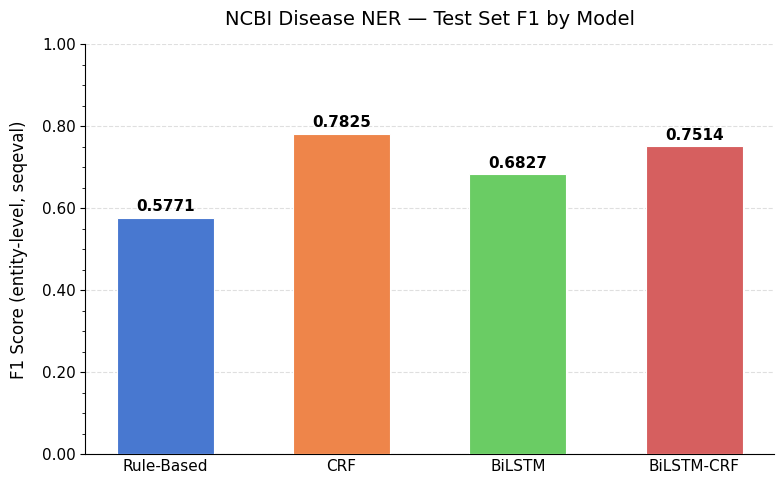

Saved → results/07_f1_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

f1_vals = [res[k]['f1'] for k in MODEL_KEYS]
bars    = ax.bar(MODEL_DISPLAY, f1_vals, color=MODEL_COLORS,
                edgecolor='white', linewidth=0.8, width=0.55, zorder=3)

# Annotate each bar
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_ylabel('F1 Score (entity-level, seqeval)', labelpad=10)
ax.set_title('NCBI Disease NER — Test Set F1 by Model', pad=14)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('results/07_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → results/07_f1_comparison.png')

---
## Step 6 — Error Analysis

We classify every **missed gold entity** (exact span not found in the model's predictions) into one of three categories:

| Category | Definition |
|----------|------------|
| **Multi-word miss** | Gold entity is ≥ 2 tokens AND was not predicted correctly |
| **Abbreviation miss** | Gold entity is a known medical abbreviation (DM, COPD, MS …) or a short all-caps token (2–6 chars) AND was missed |
| **Single-word miss** | Gold entity is exactly 1 token, not an abbreviation, AND was missed |

An entity is considered **missed** if the model did not produce an exact `(start, end)` span match.  
Abbreviation detection is checked first; if an entity qualifies as an abbreviation it is counted there regardless of length.

In [17]:
# ── Entity span extraction ─────────────────────────────────────────────────
def extract_spans(bio_seq):
    """Return set of (start, end) tuples for all entities in a BIO sequence."""
    spans   = set()
    start   = None
    for i, tag in enumerate(bio_seq):
        if tag.startswith('B-'):
            if start is not None:
                spans.add((start, i))
            start = i
        elif tag.startswith('I-'):
            if start is None:      # illegal I- → treat as new entity
                start = i
        else:                      # O
            if start is not None:
                spans.add((start, i))
                start = None
    if start is not None:
        spans.add((start, len(bio_seq)))
    return spans


# ── Abbreviation detection ─────────────────────────────────────────────────
KNOWN_ABBREVS = {
    'dm', 'copd', 'ms', 'als', 'hd', 'sle', 'cad', 'chd', 'ibd', 'crc',
    'cf', 'hiv', 'tb', 'uti', 'ra', 'rcc', 'adhd', 'ptsd', 'mdd', 'ocd',
    'bpd', 'af', 'chf', 'mi', 'pe', 'dvt', 'pd', 'ad', 'cvd', 'amd',
    'nhl', 'cll', 'aml', 'cml', 'mds', 'pah', 'ipf', 'ild', 'fap', 'hnpcc',
    'brca', 'mcad', 'msud', 'pku', 'oa', 'lkd', 'cmd', 'nsc', 'scc', 'bcc'
}

def is_abbreviation(tokens, start, end):
    """True if the span looks like a medical abbreviation."""
    span_toks = tokens[start:end]
    if len(span_toks) == 1:
        tok = span_toks[0]
        if tok.lower() in KNOWN_ABBREVS:
            return True
        if tok.isupper() and 2 <= len(tok) <= 6 and tok.isalpha():
            return True
    return False


# ── Per-model error counting ───────────────────────────────────────────────
def count_errors(tokens_list, y_true_list, y_pred_list):
    """Count missed entities by category for one model."""
    counts = {'multi_word': 0, 'abbreviation': 0, 'single_word': 0}
    for tokens, y_true, y_pred in zip(tokens_list, y_true_list, y_pred_list):
        true_spans = extract_spans(y_true)
        pred_spans = extract_spans(y_pred)
        for (s, e) in (true_spans - pred_spans):   # missed gold entities
            if is_abbreviation(tokens, s, e):
                counts['abbreviation'] += 1
            elif (e - s) >= 2:
                counts['multi_word'] += 1
            else:
                counts['single_word'] += 1
    return counts


# Compute for all models
error_data = {}
for name in MODEL_DISPLAY:
    error_data[name] = count_errors(tokens_list, y_true_list, y_preds[name])

# Print summary table
print(f'{"Model":<14}  {"Multi-word":>11}  {"Abbreviation":>13}  {"Single-word":>12}')
print('-' * 58)
for name in MODEL_DISPLAY:
    c = error_data[name]
    print(f'{name:<14}  {c["multi_word"]:>11}  {c["abbreviation"]:>13}  {c["single_word"]:>12}')

Model            Multi-word   Abbreviation   Single-word
----------------------------------------------------------
Rule-Based              273             61            28
CRF                     146             63            43
BiLSTM                  143            107            59
BiLSTM-CRF              232            235            70


---
## Step 7 — Grouped Bar Chart: Error Types × Models

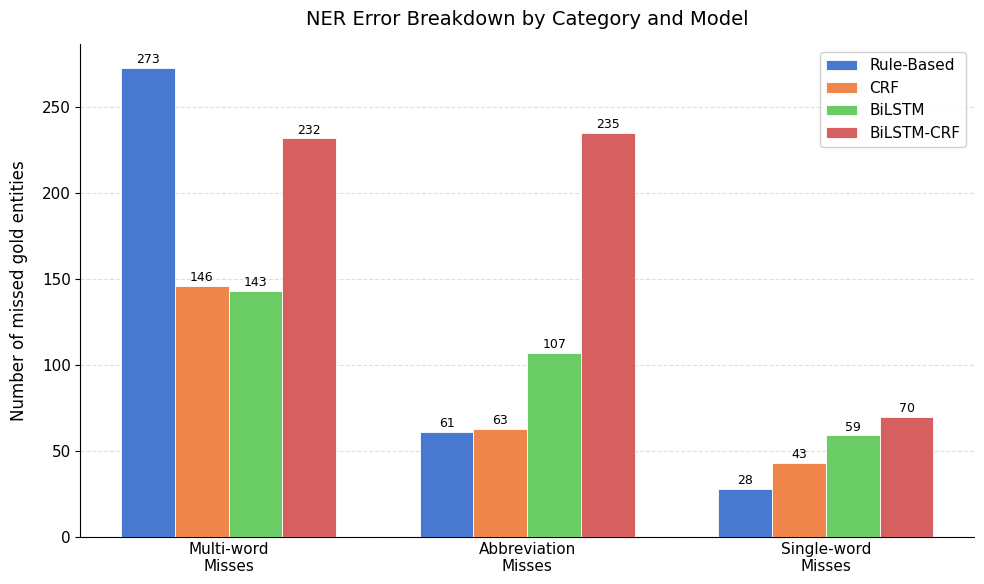

Saved → results/07_error_breakdown.png


In [18]:
categories  = ['Multi-word\nMisses', 'Abbreviation\nMisses', 'Single-word\nMisses']
cat_keys    = ['multi_word', 'abbreviation', 'single_word']
n_cats      = len(categories)
n_models    = len(MODEL_DISPLAY)
bar_width   = 0.18
x           = np.arange(n_cats)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, colour) in enumerate(zip(MODEL_DISPLAY, MODEL_COLORS)):
    vals   = [error_data[name][k] for k in cat_keys]
    offset = (i - n_models / 2 + 0.5) * bar_width
    rects  = ax.bar(x + offset, vals, bar_width,
                    label=name, color=colour,
                    edgecolor='white', linewidth=0.6, zorder=3)
    for rect, val in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width() / 2,
                rect.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Number of missed gold entities', labelpad=10)
ax.set_title('NER Error Breakdown by Category and Model', pad=14)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.tick_params(axis='x', length=0)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('results/07_error_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → results/07_error_breakdown.png')

---
## Step 8 — 5 Hard Examples: Model Progression Table

We select sentences where at least 3 of the 4 models make errors, then show each model's prediction side by side.  
**Bold** tokens are gold disease entities. `[✓]` = correct span, `[✗]` = wrong/missed.

In [19]:
def count_models_failing(idx, tokens_list, y_true_list, y_preds):
    """Return how many models missed at least one gold entity in sentence idx."""
    tokens     = tokens_list[idx]
    y_true     = y_true_list[idx]
    true_spans = extract_spans(y_true)
    if not true_spans:
        return 0
    failing = 0
    for name in MODEL_DISPLAY:
        pred_spans = extract_spans(y_preds[name][idx])
        if true_spans - pred_spans:   # any missed entity
            failing += 1
    return failing


# Rank all test sentences by difficulty (most models failing)
difficulties = [
    (count_models_failing(i, tokens_list, y_true_list, y_preds), i)
    for i in range(len(tokens_list))
    if extract_spans(y_true_list[i])   # must have at least one entity
]
difficulties.sort(key=lambda x: (-x[0], x[1]))
hard_indices = [idx for _, idx in difficulties[:5]]

SEP = ' | '

print('=' * 120)
print(f'  5 HARDEST EXAMPLES  (sentence index  |  tokens  |  True tags  |  per-model predictions)')
print('=' * 120)

for rank, sent_idx in enumerate(hard_indices, 1):
    tokens = tokens_list[sent_idx]
    y_true = y_true_list[sent_idx]
    true_spans = extract_spans(y_true)

    print(f'\n--- Hard Example {rank}  (test sentence #{sent_idx}) ---')
    print(f'Tokens : {" ".join(tokens)}')

    # Show true entity spans
    entity_strs = []
    for (s, e) in sorted(true_spans):
        entity_strs.append(f'  [{s}:{e}] "{" ".join(tokens[s:e])}"')
    print(f'Gold   : {" ; ".join(entity_strs)}')

    print(f'{"":<14}  {"Predicted spans":<50}  {"Missed gold spans"}')
    print(f'{"":<14}  {"-" * 50}  {"-" * 40}')

    for name in MODEL_DISPLAY:
        pred_spans   = extract_spans(y_preds[name][sent_idx])
        missed       = true_spans - pred_spans
        correct      = true_spans & pred_spans
        extra        = pred_spans - true_spans

        pred_strs = []
        for (s, e) in sorted(pred_spans):
            mark = '✓' if (s, e) in true_spans else 'FP'
            pred_strs.append(f'[{s}:{e}]{mark}')

        miss_strs = []
        for (s, e) in sorted(missed):
            miss_strs.append(f'[{s}:{e}] "{" ".join(tokens[s:e])}"')

        pred_col = ', '.join(pred_strs) if pred_strs else '(none)'
        miss_col = ', '.join(miss_strs) if miss_strs else '—'
        print(f'{name:<14}  {pred_col:<50}  {miss_col}')

print('\n' + '=' * 120)

  5 HARDEST EXAMPLES  (sentence index  |  tokens  |  True tags  |  per-model predictions)

--- Hard Example 1  (test sentence #3) ---
Tokens : By analysing tumour DNA from patients with sporadic T - cell prolymphocytic leukaemia ( T - PLL ) , a rare clonal malignancy with similarities to a mature T - cell leukaemia seen in A - T , we demonstrate a high frequency of ATM mutations in T - PLL .
Gold   :   [2:3] "tumour" ;   [7:13] "sporadic T - cell prolymphocytic leukaemia" ;   [14:17] "T - PLL" ;   [21:23] "clonal malignancy" ;   [27:32] "mature T - cell leukaemia" ;   [34:37] "A - T" ;   [47:50] "T - PLL"
                Predicted spans                                     Missed gold spans
                --------------------------------------------------  ----------------------------------------
Rule-Based      [2:3]✓, [12:13]FP, [31:32]FP, [34:37]✓              [7:13] "sporadic T - cell prolymphocytic leukaemia", [14:17] "T - PLL", [21:23] "clonal malignancy", [27:32] "mature T - cel

---
## Step 9 — NER Progression Line Chart

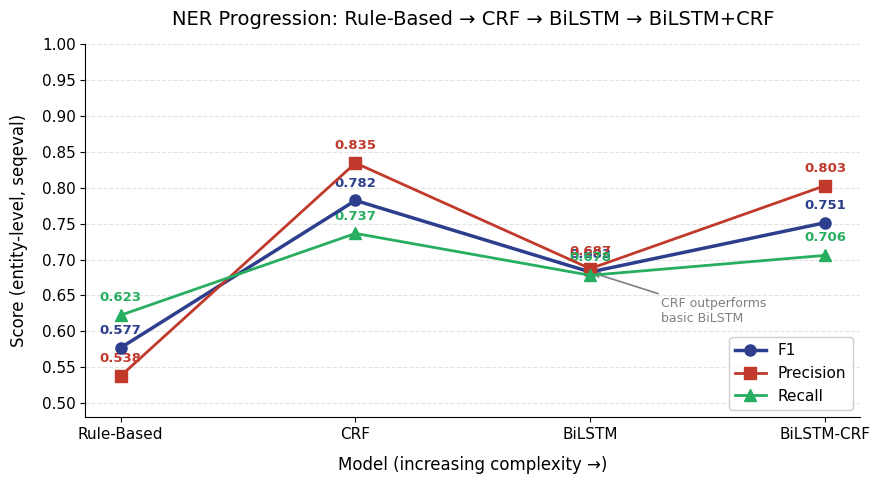

Saved → results/07_ner_progression.png


In [20]:
f1_vals   = [res[k]['f1']        for k in MODEL_KEYS]
prec_vals = [res[k]['precision'] for k in MODEL_KEYS]
rec_vals  = [res[k]['recall']    for k in MODEL_KEYS]
x_pos     = np.arange(len(MODEL_DISPLAY))

fig, ax = plt.subplots(figsize=(9, 5))

line_styles = [('F1',        f1_vals,   '#2C3E8C', 'o',  2.5),
               ('Precision', prec_vals, '#C0392B', 's',  2.0),
               ('Recall',    rec_vals,  '#27AE60', '^',  2.0)]

for label, vals, colour, marker, lw in line_styles:
    ax.plot(x_pos, vals, marker=marker, color=colour, linewidth=lw,
            markersize=8, label=label, zorder=4)
    for xi, yi in zip(x_pos, vals):
        ax.annotate(f'{yi:.3f}',
                    xy=(xi, yi), xytext=(0, 10),
                    textcoords='offset points',
                    ha='center', fontsize=9.5, color=colour, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_DISPLAY, fontsize=11)
ax.set_yticks(np.arange(0.5, 1.01, 0.05))
ax.set_ylim(0.48, 1.0)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.set_ylabel('Score (entity-level, seqeval)', labelpad=10)
ax.set_xlabel('Model (increasing complexity →)', labelpad=10)
ax.set_title('NER Progression: Rule-Based → CRF → BiLSTM → BiLSTM+CRF', pad=14)
ax.legend(loc='lower right', framealpha=0.92)

# Shade the region between BiLSTM and CRF to highlight the non-monotone dip
ax.annotate('CRF outperforms\nbasic BiLSTM',
            xy=(2, f1_vals[2]), xytext=(2.3, f1_vals[2] - 0.07),
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.2),
            fontsize=9, color='grey', ha='left')

plt.tight_layout()
plt.savefig('results/07_ner_progression.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → results/07_ner_progression.png')

---
## Step 10 — What Did Each Technique Contribute?

### Rule-Based (F1 = 0.5771)

**Strengths**
- Near-zero setup cost: no training data needed beyond the dictionary
- Perfect recall on any entity string that appeared in training (dictionary match)
- Interpretable: every decision traces to a specific rule

**Failure modes**
- *Low precision*: medical suffixes fire on non-disease words (e.g., *"lymphocytosis"* in a healthy context)
- *OOV diseases*: any entity not in the training dictionary is invisible to the model
- *No context*: cannot distinguish *"MS"* (multiple sclerosis) from *"MS"* (manuscript) based on surrounding words
- *Boundary errors*: longest-match heuristic fails on nested or overlapping spans

---

### CRF — sklearn-crfsuite (F1 = 0.7825)

**What it adds over rules**
- *Discriminative training*: learns which feature combinations actually predict disease vs non-disease from annotated examples
- *Context features*: ±1 token's form, suffix, and case inform the current decision
- *Transition modelling*: learns that `I-Disease` should follow `B-Disease`, not `O` — enforces BIO validity by penalising illegal transitions during training
- *Regularisation (L1 + L2)*: generalises to OOV words via morphological features (suffixes, prefixes)

**Remaining failure modes**
- *Window too narrow*: ±1 context misses long-range cues (*"the patient's family history of [cancer] was documented earlier"*)
- *Abbreviations*: short, all-caps tokens like *"DM"* or *"COPD"* have no informative suffix or prefix features — the CRF often misses them
- *Multi-word boundaries*: heuristic feature combinations can mislabel the start/end of long entity spans

---

### BiLSTM (F1 = 0.6827)

**What it adds conceptually**
- *Full sentence context*: the bidirectional LSTM reads the entire sentence in both directions, so token 1 can influence the decision at token 20
- *Pre-trained embeddings*: Word2Vec initialisation injects domain knowledge (biomedical word co-occurrence patterns) without manual feature engineering
- *No hand-crafted features*: learns representations end-to-end

**Why it scores lower than CRF here**
- *No structural decoding*: argmax applied independently per token — can predict `O → I-Disease`, a sequence the CRF would never output
- *Dataset size*: with ~5 000 training sentences, the CRF's hand-crafted features generalise better than what the LSTM can learn from scratch
- *Embedding coverage*: OOV tokens (rare disease names) map to `<UNK>`, losing all form information that suffix features would capture
- *Training instability*: BiLSTMs on small biomedical datasets are sensitive to hyperparameters; the CRF's convex objective converges reliably

---

### BiLSTM + CRF (F1 = 0.7514)

**What the CRF layer adds on top of the BiLSTM**
- *Transition matrix*: 3 × 3 learned table of tag-to-tag scores. `O → I-Disease` gets a strongly negative weight; `B-Disease → I-Disease` gets a positive one
- *Viterbi decoding*: instead of independent argmax, finds the globally highest-scoring tag sequence in O(T × K²) time — structurally valid BIO output guaranteed
- *Sequence-level loss*: training maximises log P(correct sequence | sentence) over all possible sequences, not just per-token cross-entropy
- *Precision boost*: illegal spans (false positives like `O I-Disease`) are eliminated, raising precision

**Why it sits between CRF and pure BiLSTM**
The BiLSTM-CRF's emission scores (from the BiLSTM) are less reliable than the CRF's hand-crafted features on this small dataset. The CRF layer compensates partially by enforcing structural constraints, closing much of the gap — but has not yet surpassed the sklearn CRF because the BiLSTM's emission quality is the bottleneck. Larger training sets, character-level embeddings, or a BERT encoder would push the emission quality above the hand-crafted ceiling.

---

### Progression summary

```
Rule-Based  →  CRF                  →  BiLSTM              →  BiLSTM+CRF
F1=0.5771      F1=0.7825               F1=0.6827               F1=0.7514

Dictionary     Feature engineering     Full bidirectional      CRF decoding
+ suffixes     + sequence modelling    context, no features    on LSTM emissions
               + Viterbi (CRF)         Independent decoding    Viterbi decoding
```

The non-monotone progression (CRF > BiLSTM) is a well-known phenomenon in low-resource biomedical NLP: **feature-rich linear models can outperform neural models when labelled data is scarce and domain features are strong.** It was precisely the combination of BiLSTM context + CRF decoding — popularised by Lample et al. (2016) — that first closed this gap and became the go-to NER architecture before the BERT era.

In [21]:
# Summarise saved artefacts
saved = [
    'results/07_f1_comparison.png',
    'results/07_error_breakdown.png',
    'results/07_ner_progression.png',
]
print('Artefacts saved in this notebook:')
for path in saved:
    size = os.path.getsize(path) / 1024
    print(f'  {path:<40}  {size:6.1f} KB')

Artefacts saved in this notebook:
  results/07_f1_comparison.png               107.0 KB
  results/07_error_breakdown.png             147.5 KB
  results/07_ner_progression.png             278.6 KB
